In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE, MutualInfoClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer

In [55]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('ggplot')
sns.set_palette("husl")

# Define Column Names for NSL-KDD (Standard List)
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]
# Load Data (Assuming data is in ../SentinelNet/data or ../data relative to notebook)
# You might need to adjust the path based on your exact folder structure
train_path = './data/KDDTrain+.txt'
test_path = './data/KDDTest+.txt'

# Try loading with error handling for paths
try:
    df_train = pd.read_csv(train_path, header=None, names=COL_NAMES)
    df_test = pd.read_csv(test_path, header=None, names=COL_NAMES)
    print(f"Training Data Shape: {df_train.head()}")
    print(f"Test Data Shape: {df_test.tail()}")
except FileNotFoundError:
    print("Files not found. Please check the paths. Trying absolute paths or checking local directory...")
    # Fallback to local directory if paths are different
    if os.path.exists('KDDTrain+.txt'):
        df_train = pd.read_csv('KDDTrain+.txt', header=None, names=COL_NAMES)
        df_test = pd.read_csv('KDDTest+.txt', header=None, names=COL_NAMES)

# Combine for initial analysis (optional, but good for understanding full global distributions)

Training Data Shape:    duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0

In [58]:
exclude_cols = ['label', 'attack_class', 'difficulty_level', 'is_outlier']
print(exclude_cols)

['label', 'attack_class', 'difficulty_level', 'is_outlier']


In [60]:
# Target variable
y = df_train['label']

# Feature columns
X = df_train.drop(columns=['label'])

In [62]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

y_encoded = labelencoder.fit_transform(y)

In [64]:
# Separate input features and target column
target_col = 'label'

feature_data = df_train.drop(columns=[target_col])
target_data = df_train[target_col]

In [66]:
# Identify categorical columns from X (features)

cat_cols = X.select_dtypes(include=['object']).columns

print("Categorical Columns:", list(cat_cols))

Categorical Columns: ['protocol_type', 'service', 'flag']


In [68]:
from sklearn.preprocessing import LabelEncoder

# Identify text-based columns
text_columns = feature_data.select_dtypes(include='object').columns

encoder_map = {}

for column in text_columns:
    
    encoder = LabelEncoder()
    
    feature_data[column] = encoder.fit_transform(feature_data[column])
    
    encoder_map[column] = encoder

In [70]:
target_encoder = LabelEncoder()

encoded_target = target_encoder.fit_transform(target_data)

In [72]:
from sklearn.model_selection import train_test_split

train_features, test_features, train_labels, test_labels = train_test_split(
    feature_data,
    encoded_target,
    test_size=0.25,
    random_state=7,
    stratify=encoded_target
)

In [74]:
from sklearn.ensemble import RandomForestClassifier

def build_rf_model(X, y):
    
    rf = RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        random_state=7
    )
    
    rf.fit(X, y)
    
    return rf

In [76]:
rf_classifier = build_rf_model(train_features, train_labels)

In [78]:
importance_scores = pd.Series(
    rf_classifier.feature_importances_,
    index=train_features.columns
)

sorted_importance = importance_scores.sort_values(ascending=False)

print(sorted_importance.head(10))

src_bytes                      0.136449
diff_srv_rate                  0.107400
same_srv_rate                  0.090522
flag                           0.085401
serror_rate                    0.045805
dst_host_serror_rate           0.044809
difficulty_level               0.038383
dst_host_diff_srv_rate         0.036202
count                          0.034404
dst_host_same_src_port_rate    0.033465
dtype: float64


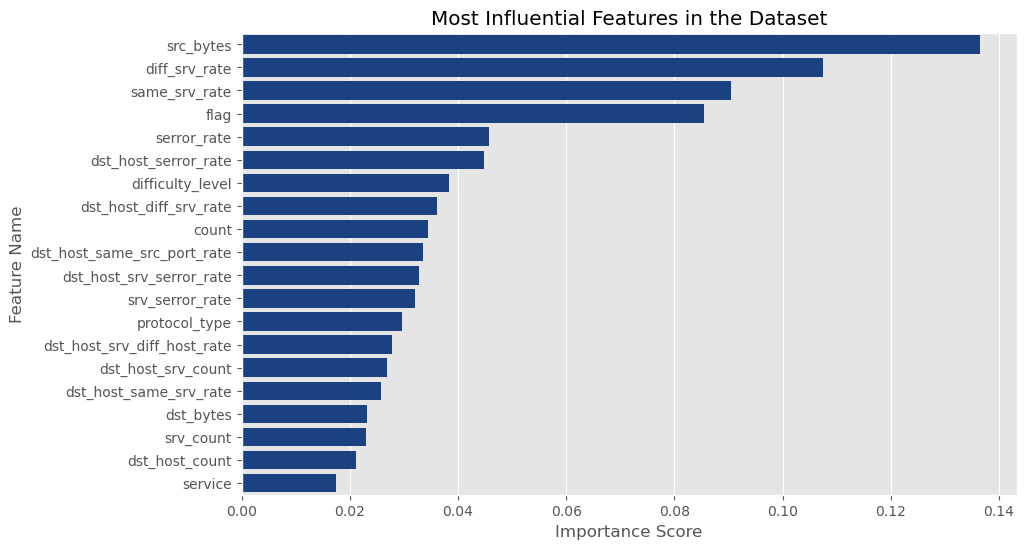

In [80]:
# Select top important features
top_features = sorted_importance.head(20).reset_index()

top_features.columns = ["Feature","Score"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Score",
    y="Feature",
    color="#0b3d91"   # dark blue color
)

plt.title("Most Influential Features in the Dataset")

plt.xlabel("Importance Score")
plt.ylabel("Feature Name")

plt.show()

In [82]:
importance_limit = 0.001

weak_features = sorted_importance[sorted_importance < importance_limit]

print("Features with very low importance:")
print(weak_features)

Features with very low importance:
is_guest_login        0.000713
num_failed_logins     0.000204
num_root              0.000114
land                  0.000075
num_file_creations    0.000063
root_shell            0.000043
num_shells            0.000025
num_access_files      0.000022
su_attempted          0.000017
urgent                0.000006
is_host_login         0.000000
num_outbound_cmds     0.000000
dtype: float64


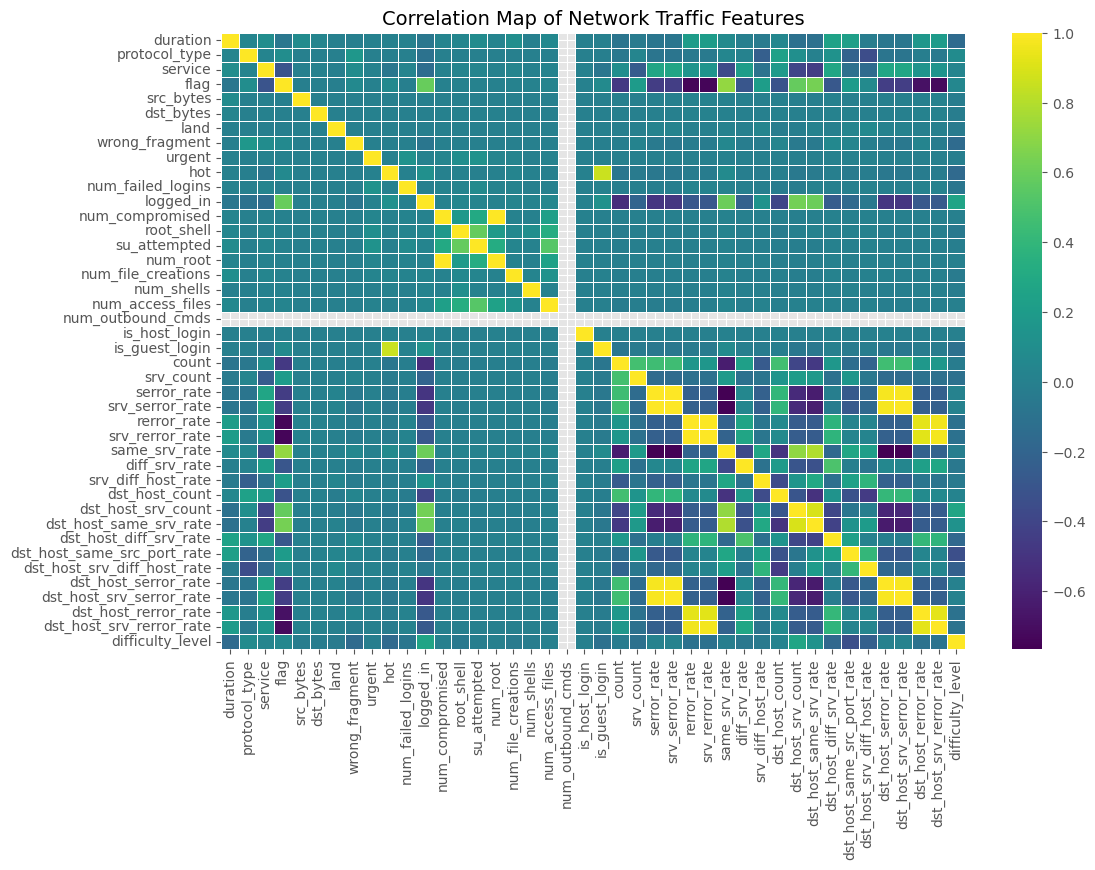

In [84]:
# Extra analysis: Feature correlation visualization

plt.figure(figsize=(12,8))

sns.heatmap(
    train_features.corr(),
    cmap="viridis",      # completely different color scheme
    linewidths=0.4,
    linecolor="white"
)

plt.title("Correlation Map of Network Traffic Features", fontsize=14)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

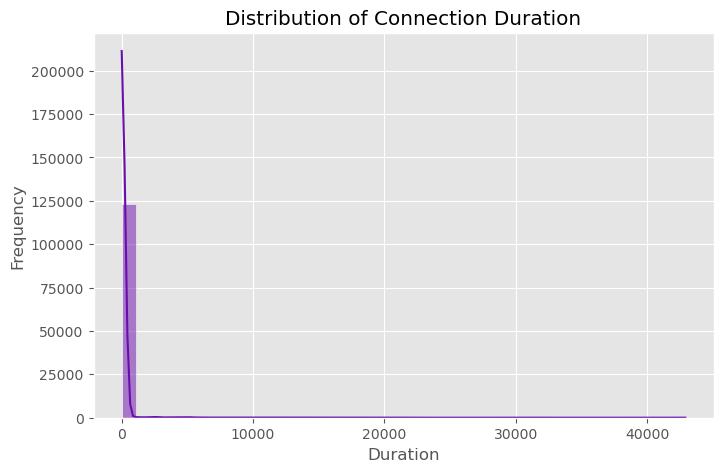

In [86]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_train["duration"],
    bins=40,
    kde=True,
    color="#6a0dad"
)

plt.title("Distribution of Connection Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")

plt.show()

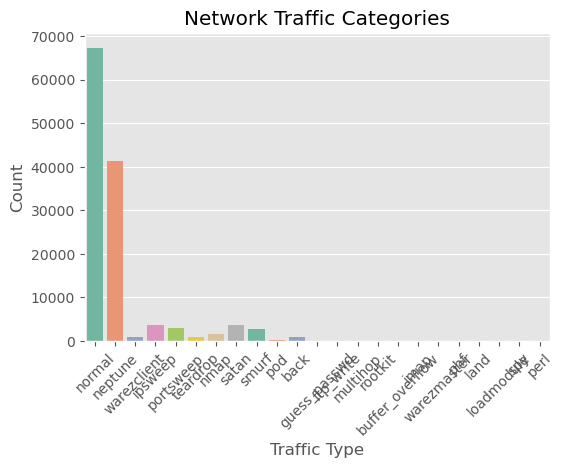

In [88]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=df_train,
    palette="Set2"
)

plt.title("Network Traffic Categories")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

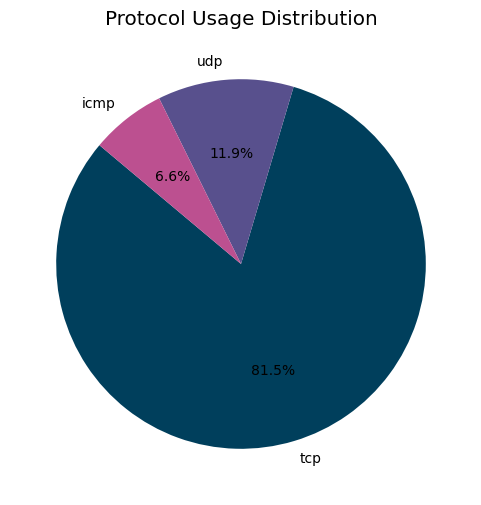

In [90]:
protocol_counts = df_train["protocol_type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    protocol_counts,
    labels=protocol_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#003f5c","#58508d","#bc5090"]
)

plt.title("Protocol Usage Distribution")

plt.show()

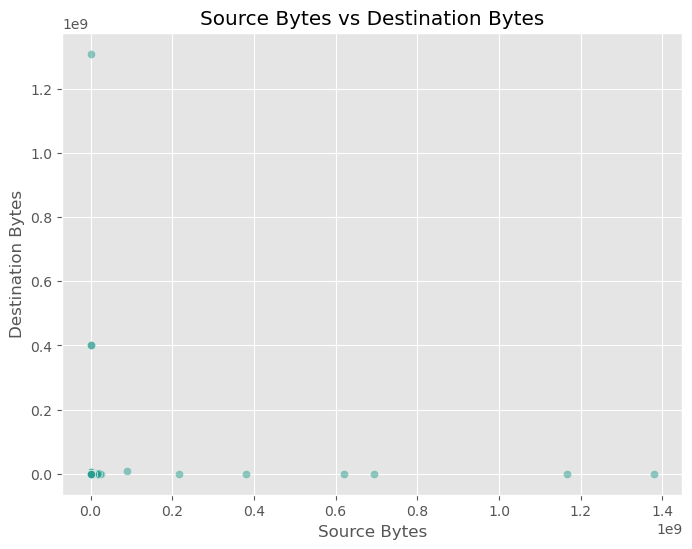

In [92]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="src_bytes",
    y="dst_bytes",
    data=df_train,
    alpha=0.5,
    color="#2a9d8f"
)

plt.title("Source Bytes vs Destination Bytes")
plt.xlabel("Source Bytes")
plt.ylabel("Destination Bytes")

plt.show()

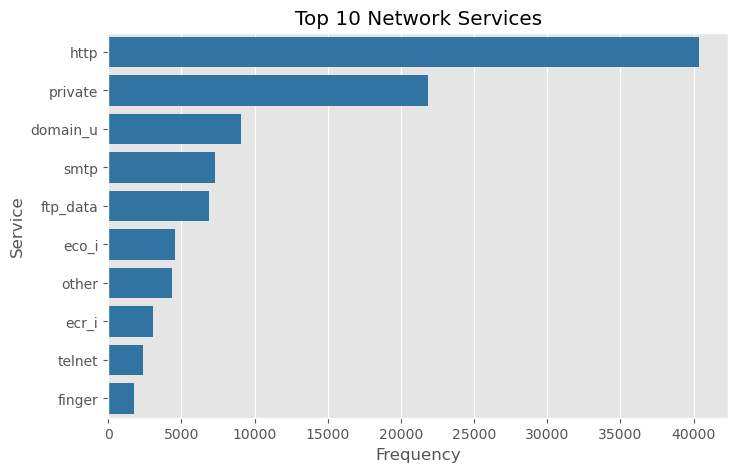

In [94]:
top_services = df_train["service"].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_services.values,
    y=top_services.index,
    color="#1f77b4"
)

plt.title("Top 10 Network Services")
plt.xlabel("Frequency")
plt.ylabel("Service")

plt.show()

In [96]:
from sklearn.model_selection import train_test_split

print("Splitting dataset into training and testing sets...")

X_train_data, X_test_data, y_train_data, y_test_data = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=7,
    stratify=y_encoded
)

print("Training samples :", X_train_data.shape)
print("Testing samples  :", X_test_data.shape)

Splitting dataset into training and testing sets...
Training samples : (100778, 42)
Testing samples  : (25195, 42)


In [98]:
# Encode categorical columns

X_encoded = pd.get_dummies(X)

print("Encoded Feature Shape:", X_encoded.shape)

Encoded Feature Shape: (125973, 123)


In [100]:
from sklearn.model_selection import train_test_split

print("Splitting dataset...")

X_train_data, X_test_data, y_train_data, y_test_data = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=7,
    stratify=y_encoded
)

print("Training samples :", X_train_data.shape)
print("Testing samples  :", X_test_data.shape)

Splitting dataset...
Training samples : (100778, 123)
Testing samples  : (25195, 123)


In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning...")

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    "n_estimators": [80,120],
    "max_depth": [12,20],
    "min_samples_leaf": [1,3]
}

grid_search_model = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=1
)

grid_search_model.fit(X_train_data, y_train_data)

print("Grid Search Completed")
print("Best Parameters:", grid_search_model.best_params_)

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Grid Search Completed
Best Parameters: {'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 120}


In [104]:
final_intrusion_model = grid_search_model.best_estimator_

print("Best Model Selected")
print(final_intrusion_model)

Best Model Selected
RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=3, n_estimators=120, n_jobs=-1,
                       random_state=42)


In [106]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = final_intrusion_model.predict(X_test_data)

print("Model Accuracy:", final_intrusion_model.score(X_test_data, y_test_data))

print("\nClassification Report:\n")
print(classification_report(y_test_data, predictions))

Model Accuracy: 0.9963087914268705

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       191
           1       0.83      0.83      0.83         6
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00         2
           5       0.97      1.00      0.98       720
           6       1.00      1.00      1.00         4
           7       0.50      0.50      0.50         2
           8       0.50      1.00      0.67         1
           9       1.00      1.00      1.00      8243
          10       0.98      0.97      0.98       299
          11       1.00      0.99      1.00     13469
          13       1.00      1.00      1.00         1
          14       0.91      1.00      0.95        40
          15       0.99      0.99      0.99       586
          16       0.33      0.50      0.40         2
          17       0.

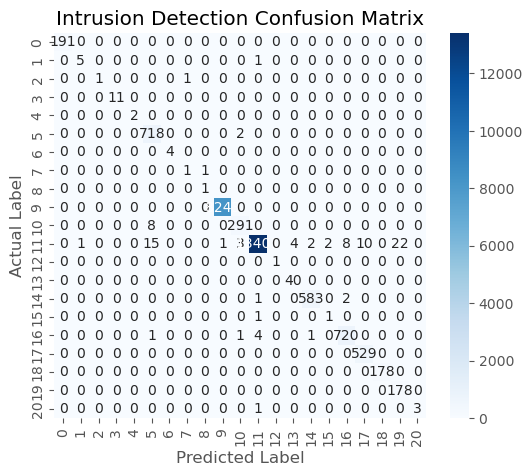

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_data, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Intrusion Detection Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

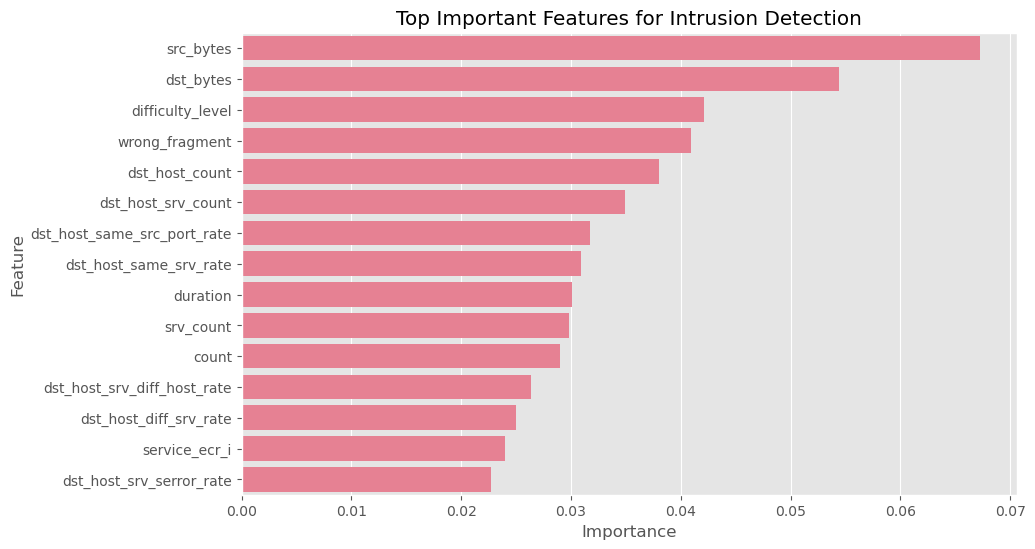

In [108]:
importances = final_intrusion_model.feature_importances_

feature_names = X_encoded.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(15))

plt.title("Top Important Features for Intrusion Detection")

plt.show()

In [110]:
import joblib

joblib.dump(final_intrusion_model, "sentinel_intrusion_model.joblib")

print("Model saved successfully")

Model saved successfully


In [112]:
sample_prediction = final_intrusion_model.predict(X_test_data[:5])

print("Sample Predictions:", sample_prediction)

Sample Predictions: [11 11 15 11  9]


In [114]:


def build_extra_features(df):
    df_copy = df.copy()
    
    # Total bytes transferred
    df_copy["total_bytes"] = df_copy["src_bytes"] + df_copy["dst_bytes"]
    
    # Difference in bytes
    df_copy["byte_difference"] = df_copy["src_bytes"] - df_copy["dst_bytes"]
    
    # Connection load
    df_copy["connection_load"] = df_copy["count"] + df_copy["srv_count"]
    
    return df_copy

# Apply on original dataset
X_new = build_extra_features(X)

print("New features added successfully")

New features added successfully


In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify columns again
categorical_columns = X_new.select_dtypes(include=['object']).columns
numerical_columns = X_new.select_dtypes(exclude=['object']).columns

print("Categorical:", categorical_columns)
print("Numerical:", numerical_columns)

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ("num", StandardScaler(), numerical_columns)
    ]
)

Categorical: Index(['protocol_type', 'service', 'flag'], dtype='object')
Numerical: Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'difficulty_level', 'total_bytes',
       'byte_difference', 'connection_load'],
      dtype='object')


In [118]:
# Apply preprocessing again on new features
X_new_processed = preprocessor.fit_transform(X_new)

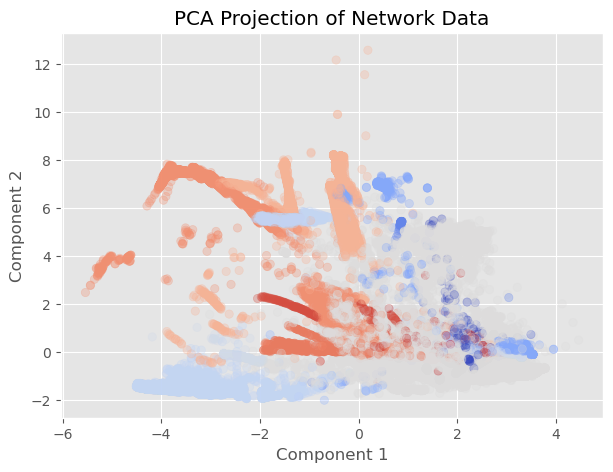

In [120]:
from sklearn.decomposition import PCA

pca_model = PCA(n_components=2)
pca_output = pca_model.fit_transform(X_new_processed)

plt.figure(figsize=(7,5))
plt.scatter(pca_output[:, 0], pca_output[:, 1], alpha=0.3, c=y_encoded, cmap='coolwarm')

plt.title("PCA Projection of Network Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


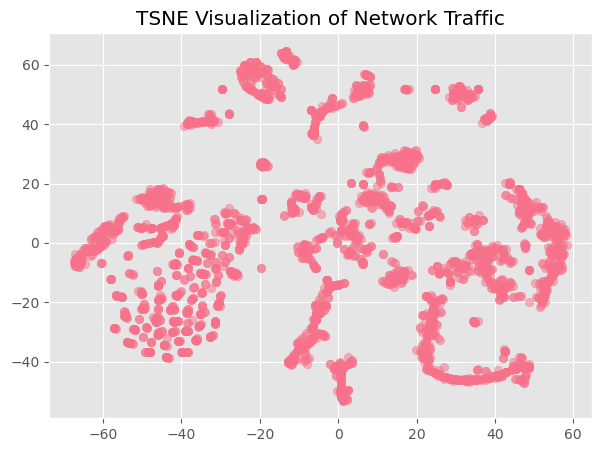

In [122]:
from sklearn.manifold import TSNE

tsne_model = TSNE(n_components=2, perplexity=30, random_state=10)
tsne_output = tsne_model.fit_transform(X_new_processed[:3000])

plt.figure(figsize=(7,5))
plt.scatter(tsne_output[:,0], tsne_output[:,1], alpha=0.5)

plt.title("TSNE Visualization of Network Traffic")
plt.show()

In [124]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.04, random_state=10)
anomaly_pred = iso_model.fit_predict(X_new_processed)

# Convert output
anomaly_flag = np.where(anomaly_pred == -1, 1, 0)

print("Anomalies detected:", np.sum(anomaly_flag))

Anomalies detected: 5039


In [129]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new_processed,
    y_encoded,
    test_size=0.2,
    random_state=10,
    stratify=y_encoded
)

In [132]:
rf_new = RandomForestClassifier(n_estimators=120, max_depth=15, random_state=10)
rf_new.fit(X_train_new, y_train_new)

y_pred_new = rf_new.predict(X_test_new)

In [134]:
from sklearn.metrics import accuracy_score, classification_report

print("Improved Accuracy:", accuracy_score(y_test_new, y_pred_new))
print(classification_report(y_test_new, y_pred_new))

Improved Accuracy: 0.9990871204604088
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       191
           1       1.00      1.00      1.00         6
           2       0.00      0.00      0.00         2
           3       1.00      0.82      0.90        11
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00       720
           6       1.00      1.00      1.00         4
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         1
           9       1.00      1.00      1.00      8243
          10       1.00      0.99      0.99       299
          11       1.00      1.00      1.00     13469
          13       0.00      0.00      0.00         1
          14       1.00      1.00      1.00        40
          15       1.00      1.00      1.00       586
          16       0.00      0.00      0.00         2
          17       1.00      0.99      1.00

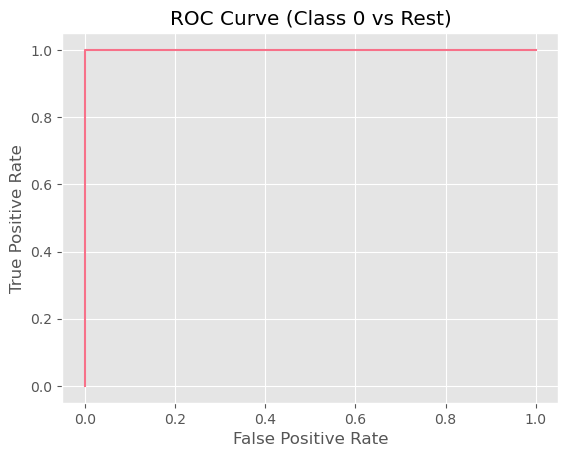

In [136]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary format
y_test_bin = label_binarize(y_test_new, classes=np.unique(y_test_new))

# Get probability predictions
y_prob = rf_new.predict_proba(X_test_new)

# Plot ROC for one class (example: class 0)
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_prob[:, 0])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve (Class 0 vs Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

IndexError: index 21 is out of bounds for axis 1 with size 21

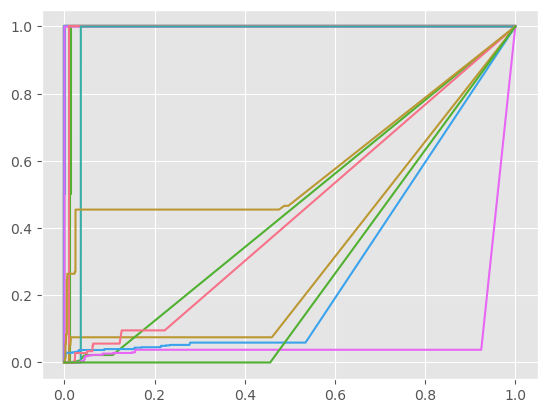

In [138]:
plt.figure()

for i in range(y_prob.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.title("ROC Curve for All Classes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [140]:
import joblib

joblib.dump(rf_new, "improved_intrusion_model.pkl")

print("Improved model saved")

Improved model saved


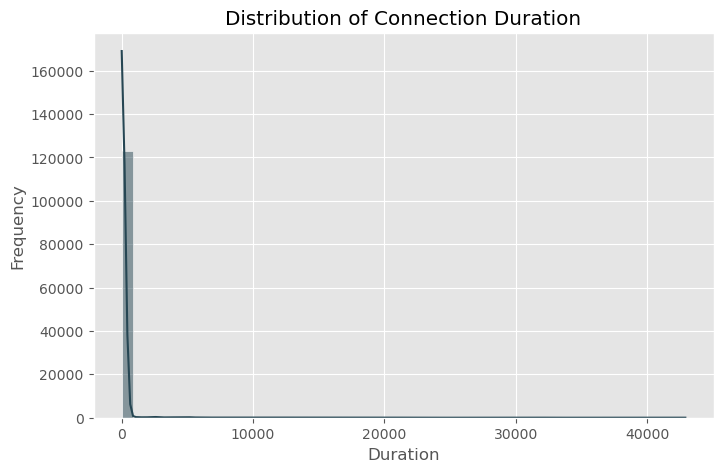

In [142]:
plt.figure(figsize=(8,5))

sns.histplot(df_train["duration"], bins=50, kde=True, color="#264653")

plt.title("Distribution of Connection Duration")
plt.xlabel("Duration")
plt.ylabel("Frequency")

plt.show()

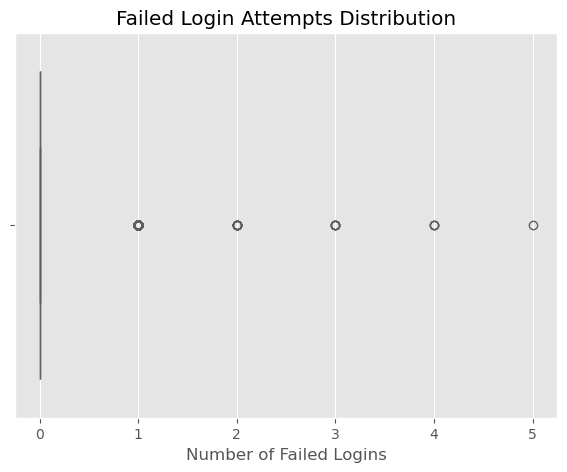

In [144]:
plt.figure(figsize=(7,5))

sns.boxplot(x=df_train["num_failed_logins"], color="#e76f51")

plt.title("Failed Login Attempts Distribution")
plt.xlabel("Number of Failed Logins")

plt.show()

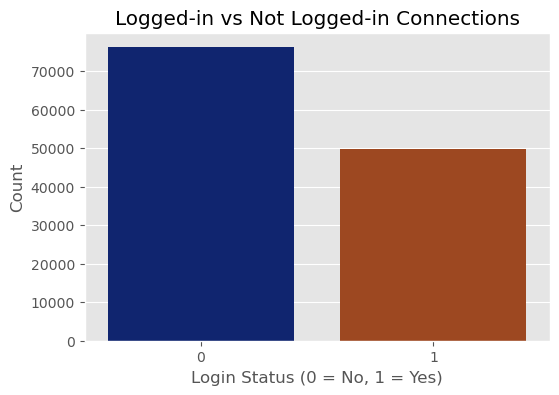

In [146]:
login_counts = df_train["logged_in"].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(x=login_counts.index, y=login_counts.values, palette="dark")

plt.title("Logged-in vs Not Logged-in Connections")
plt.xlabel("Login Status (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

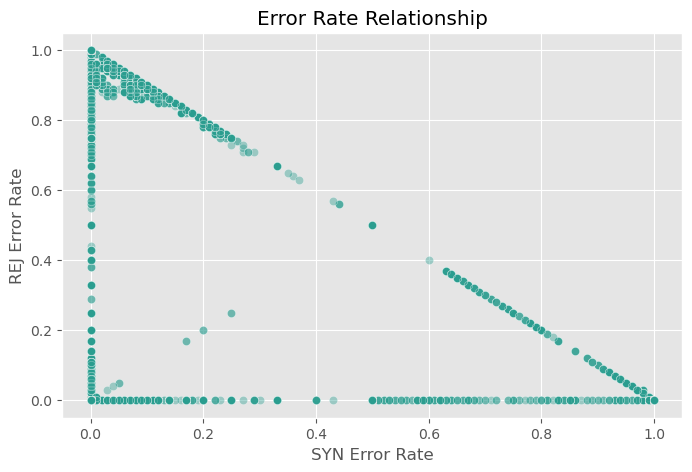

In [148]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df_train["serror_rate"],
    y=df_train["rerror_rate"],
    alpha=0.4,
    color="#2a9d8f"
)

plt.title("Error Rate Relationship")
plt.xlabel("SYN Error Rate")
plt.ylabel("REJ Error Rate")

plt.show()

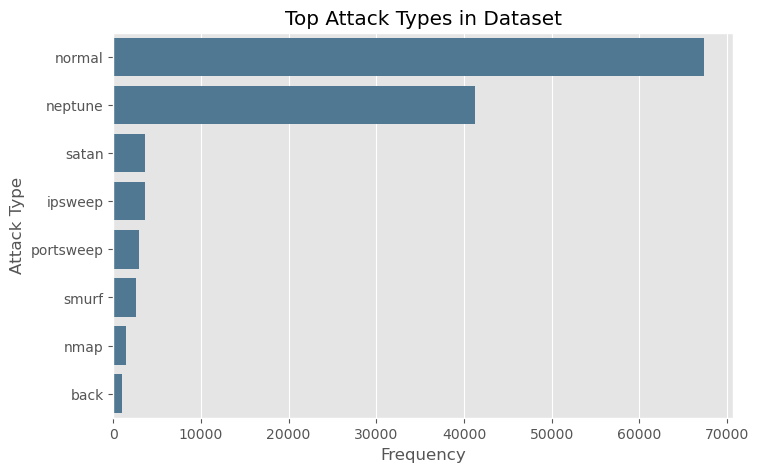

In [152]:
top_attacks = df_train["label"].value_counts().head(8)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_attacks.values,
    y=top_attacks.index,
    color="#457b9d"
)

plt.title("Top Attack Types in Dataset")
plt.xlabel("Frequency")
plt.ylabel("Attack Type")

plt.show()

In [154]:
analysis_df = pd.DataFrame({
    "attack_class": y_test_new,
    "iso_score": iso_model.decision_function(X_test_new),
    "iso_pred": iso_model.predict(X_test_new)
})

analysis_df["is_anomaly"] = analysis_df["iso_pred"].map({1: 0, -1: 1})

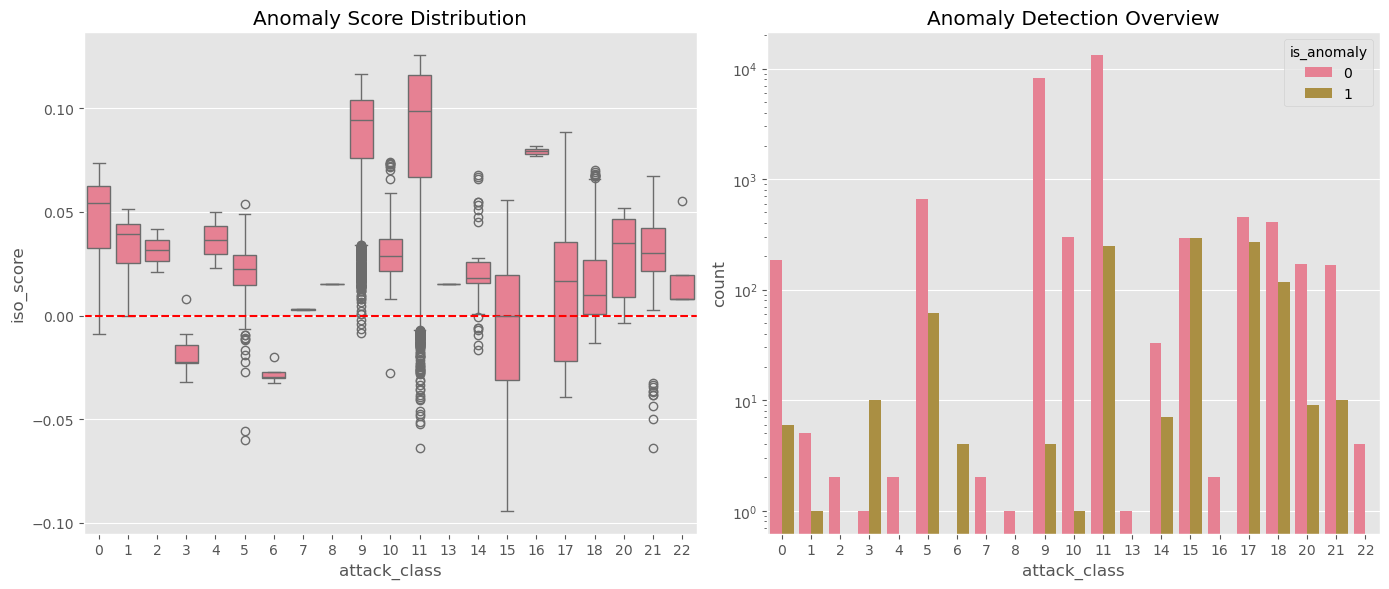

In [156]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(x="attack_class", y="iso_score", data=analysis_df)
plt.axhline(0, color='red', linestyle='--')
plt.title("Anomaly Score Distribution")

plt.subplot(1,2,2)
sns.countplot(x="attack_class", hue="is_anomaly", data=analysis_df)
plt.yscale("log")
plt.title("Anomaly Detection Overview")

plt.tight_layout()
plt.show()

In [158]:
print("Train Accuracy:", rf_new.score(X_train_new, y_train_new))
print("Test Accuracy :", rf_new.score(X_test_new, y_test_new))

Train Accuracy: 0.9998412351902201
Test Accuracy : 0.9990871204604088
